# Expediente D: Contrato que crece
## Equipo 9 | Primer avance, semana 1 del laboratorio (semana 7 del curso)
**Universidad Central - Data Analytics, 2026-2**  
**Recorte asignado:** Boyacá. **Fecha de elaboración:** 21 de septiembre de 2026.  
**Integrantes:** pendiente de completar por el equipo, junto con la fecha efectiva de entrega.

Este desarrollo conserva la ruta del notebook `SECOP_ExpedienteD`: cargar, comprender, describir, revisar calidad, relacionar contratos y adiciones, comparar y construir tres evidencias. Las respuestas e interpretaciones acompañan las salidas. Al final hay un **anexo preparatorio de semana 2**, separado del primer avance.

**Afirmación original del brief:** existen características observables al momento de la firma que se asocian posteriormente con adiciones al contrato; su desarrollo específico exige medir el componente presupuestal.

**Pregunta operativa con estos archivos:** ¿qué características de los contratos se asocian con registros de modificación localizados en la descarga? Como análisis complementario del blog se examinan los días adicionados. Ninguna de las dos medidas se presenta como aumento presupuestal probado.

**Conclusión de alcance:** se puede entregar un EDA reproducible y auditar el cruce. Con estos archivos no se identifica de forma fiable la proporción de valor adicionado sobre valor inicial ni la ocurrencia posterior de todas las adiciones. No se inventan esas variables ni se sustituyen silenciosamente por otras.

## 0. Lectura de las instrucciones y criterio operativo

| Material | Lo que solicita o permite | Aplicación en este avance |
|---|---|---|
| Brief del expediente D, apartados 3-6 | Adiciones presupuestales, valor adicionado / valor inicial, cruce verificado | Se audita el cruce y se declara no calculable la razón monetaria con los campos estructurados disponibles. |
| Notebook base específico D | Contar identificadores de adición por contrato y comparar grupos | Es la ruta principal: E1 y E2. Se usa el término preciso registro localizado. |
| Blog, apartado Expediente D | Analizar `dias_adicionados` y hablar de ampliaciones temporales | E3 es una ruta complementaria expresamente identificada, no un reemplazo de la medida presupuestal. |
| Diapositivas EDA, 11-12 | Tres decisiones defendibles, tres tarjetas, notebook y declaración de IA | Se diligencian las tres evidencias y se documentan las decisiones. |
| Último mensaje del profesor | Usar los CSV entregados; el periodo puede variar | No se cambian territorio, filtros ni archivos; se comprueba el periodo real. |

**Advertencia temporal sobre el criterio previo.** La copia recibida ya tenía resultados guardados y no contenía un criterio del equipo diligenciado. Por tanto, este documento **no demuestra un prerregistro anterior a observar los resultados**. Lo siguiente es un criterio operativo propuesto para revisión del equipo, no una decisión autónoma ya tomada ni un requisito numérico fijado por el docente.

**Variables candidatas declaradas:** modalidad, tipo de contrato, sector, entidad, año y mes de firma; valor total registrado y duración registrada como características descriptivas. El valor y la duración al corte no se llaman iniciales, pues pueden incorporar cambios posteriores. El estado, los pagos y la última actualización no se usan como predictores de información disponible al firmar.

**Magnitud de interés propuesta:** diferencia relativa de medianas de al menos 20% para descripciones monetarias; diferencia de al menos 5 puntos porcentuales para la señal temporal. Son umbrales prácticos exploratorios, no significancia estadística. No se aplica un umbral de incidencia presupuestal porque el resultado no está identificado y la cobertura no es completa. Las celdas con menos de 50 contratos se marcan como pequeñas; 50 no garantiza potencia.

**Antes de entregar:** el equipo debe discutir estos criterios, registrar una decisión realmente propia y consultar al profesor cuál de las tres definiciones de adición rige la evaluación. No se oculta el desacuerdo entre materiales.

## 1. Preparar los datos y reproducir el análisis

Ejecute todas las celdas en orden. No se descarga una versión nueva de SECOP: los resultados dependen de la misma instantánea del profesor. Estructura recomendada:

```text
Equipo9_ExpedienteD/
  SECOP_Equipo9_Avance1.ipynb
  data/
    secop_recorte.csv
    secop_adiciones.csv
    metadata_extraccion.json
    metadata_adiciones.json
```

En Colab, puede abrir el notebook y subir el ZIP completo cuando la primera celda lo solicite. En Jupyter, descomprima el paquete y abra el notebook en esa carpeta. `data` y `Data` son nombres diferentes en sistemas sensibles a mayúsculas; el cargador reconoce ambos, pero verifica el contenido por su huella SHA-256.

In [1]:
from pathlib import Path
from statistics import NormalDist
import hashlib
import io
import json
import math
import platform
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
OUT = ROOT / 'resultados'
FIG = OUT / 'figuras'
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)
UMBRAL_MEDIANA_REL = 0.20
UMBRAL_TEMPORAL_PP = 5.0
MIN_CELDA = 50

pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 12})

def fmt(n, dec=0):
    return f'{n:,.{dec}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

def save_table(name, table, index=True):
    table.to_csv(OUT / f'{name}.csv', index=index, encoding='utf-8-sig')
    display(table)

def show_figure(name):
    plt.tight_layout()
    plt.savefig(FIG / f'{name}.png', dpi=170, bbox_inches='tight')
    plt.show()
    plt.close()

def locate_data():
    candidates = [ROOT/'data', ROOT/'Data', ROOT/'equipo_9',
                  ROOT/'Equipo9_ExpedienteD'/'data', ROOT]
    for folder in candidates:
        if all((folder/f).is_file() for f in ['secop_recorte.csv', 'secop_adiciones.csv']):
            return folder
    zips = [z for z in ROOT.glob('*.zip') if 'equipo9' in z.name.lower() or 'equipo_9' in z.name.lower()]
    try:
        from google.colab import files
        is_colab = True
    except ImportError:
        is_colab = False
    if not zips and is_colab:
        print('Suba el ZIP del equipo 9, original o del paquete preparado.')
        uploaded = files.upload()
        zips = [Path(name) for name in uploaded if name.lower().endswith('.zip')]
    if len(zips) != 1:
        raise FileNotFoundError('Ubique los dos CSV en data/ o deje un unico ZIP del equipo 9 junto al notebook.')
    dest = ROOT/'data'
    dest.mkdir(exist_ok=True)
    expected = ['secop_recorte.csv', 'secop_adiciones.csv', 'metadata_extraccion.json', 'metadata_adiciones.json']
    with zipfile.ZipFile(zips[0]) as z:
        for name in expected:
            matches = [x for x in z.namelist() if Path(x).name == name]
            if len(matches) != 1:
                raise ValueError(f'El ZIP debe contener exactamente un archivo {name}.')
            # Escribe solo los cuatro nombres conocidos; no extrae rutas arbitrarias.
            (dest/name).write_bytes(z.read(matches[0]))
    return dest

DATA = locate_data()

In [2]:
EXPECTED_SHA = {'secop_adiciones.csv': '2b0c949ee4e8f09cea55f9fdbf943a54cc9b048b50f4acf5259b4cdef2a75332', 'secop_recorte.csv': '283be52453ca226a02dec6f3eda37fb9acb695ffe6f2627b182b720e4cdf96c5'}
observed_sha = {name: hashlib.sha256((DATA/name).read_bytes()).hexdigest() for name in EXPECTED_SHA}
assert observed_sha == EXPECTED_SHA, 'Los CSV no son la misma instantanea analizada. Revise la version antes de mezclar resultados.'
contracts_raw = pd.read_csv(DATA/'secop_recorte.csv', dtype='string')
additions_raw = pd.read_csv(DATA/'secop_adiciones.csv', dtype='string')
metadata_c = json.loads((DATA/'metadata_extraccion.json').read_text(encoding='utf-8-sig'))
metadata_a = json.loads((DATA/'metadata_adiciones.json').read_text(encoding='utf-8-sig'))
versions = {'python': platform.python_version(), 'pandas': pd.__version__,
            'numpy': np.__version__, 'matplotlib': matplotlib.__version__}
(OUT/'versiones_y_huellas.json').write_text(json.dumps({'versiones': versions, 'sha256': observed_sha}, indent=2), encoding='utf-8')
print('Carpeta de datos:', DATA)
print('Contratos:', contracts_raw.shape, '| Registros de modificaciones:', additions_raw.shape)
print('Metadatos contratos:', metadata_c)
print('Metadatos adiciones:', metadata_a)
print('Versiones:', versions)

Carpeta de datos: /mnt/data/Equipo9_ExpedienteD/data
Contratos: (50000, 85) | Registros de modificaciones: (50000, 5)
Metadatos contratos: {'dataset': 'jbjy-vk9h (SECOP II, Contratos Electronicos)', 'equipo': 9, 'expediente': 'D', 'territorio': 'Boyacá', 'consulta_where': "fecha_de_firma between '2024-01-01T00:00:00' and '2025-12-31T23:59:59' AND departamento = 'Boyacá'", 'fecha_extraccion_utc': '2026-09-16T03:26:21+00:00', 'registros': 50000, 'registros_disponibles': 62017, 'tope_aplicado': 50000, 'recorte_truncado': True}
Metadatos adiciones: {'dataset': 'cb9c-h8sn (SECOP II, Adiciones)', 'equipo': 9, 'filtro': '(sin filtro territorial: la tabla no incluye departamento)', 'fecha_extraccion_utc': '2026-09-16T03:26:47+00:00', 'registros': 50000, 'tope_aplicado': 50000}
Versiones: {'python': '3.13.5', 'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}


### Respuestas: ¿qué representa una fila?
En contratos, una fila representa un contrato del recorte, después de verificar que su ID es único. En adiciones, una fila es un registro de modificación; puede repetirse el mismo evento o haber varios eventos del mismo contrato.

`id_contrato` identifica el contrato; `identificador` identifica un evento. No son intercambiables. La entidad se describe por nombre y se contrasta por `nit_entidad` o `codigo_entidad`; para proveedores se revisan documento, tipo de documento y código. Un nombre distinto no prueba una entidad distinta. Ciudad corresponde al registro de la entidad, no necesariamente al lugar de ejecución.

La variable monetaria utilizada es `valor_del_contrato`, definida como valor total del contrato, no como valor inicial certificado. Los campos que exigen especial cuidado son `tipo` en adiciones, `dias_adicionados`, las fechas y el origen temporal del valor contractual.

In [3]:
# Copias de trabajo: los CSV originales no se modifican.
c = contracts_raw.copy()
a = additions_raw.copy()
for frame, columns in [(c, ['id_contrato']), (a, ['id_contrato', 'identificador'])]:
    for col in columns:
        frame[col] = frame[col].str.normalize('NFKC').str.strip().str.upper()
        assert frame[col].notna().all() and frame[col].str.len().gt(0).all(), f'Llave vacia: {col}'
assert c['id_contrato'].is_unique, 'Existen IDs repetidos; no deduplicar contratos sin revisar sus versiones.'
assert c['id_contrato'].str.fullmatch(r'CO1\.PCCNTR\.\d+').all()

conversions = []
for col in ['valor_del_contrato', 'dias_adicionados']:
    original = c[col]
    c[col] = pd.to_numeric(original, errors='coerce')
    conversions.append({'columna': col, 'no_vacios_que_no_convierten': int((original.notna() & c[col].isna()).sum())})
for col in ['fecha_de_firma', 'fecha_de_inicio_del_contrato', 'fecha_de_fin_del_contrato']:
    original = c[col]
    c[col] = pd.to_datetime(original, format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce')
    conversions.append({'columna': col, 'no_vacios_que_no_convierten': int((original.notna() & c[col].isna()).sum())})
a['fecha_registro_dt'] = pd.to_datetime(a['fecharegistro'], format='%Y-%m-%dT%H:%M:%S.%f', errors='coerce')
c['duracion_registrada_dias'] = (c['fecha_de_fin_del_contrato'] - c['fecha_de_inicio_del_contrato']).dt.days
c['duracion_valida_dias'] = c['duracion_registrada_dias'].where(c['duracion_registrada_dias'] > 0)
c['anio_firma'] = c['fecha_de_firma'].dt.year.astype('Int64')
c['mes_firma'] = c['fecha_de_firma'].dt.month.astype('Int64')
c['con_dias_adicionados'] = c['dias_adicionados'].gt(0).astype('boolean')
c.loc[c['dias_adicionados'].isna(), 'con_dias_adicionados'] = pd.NA
save_table('conversiones', pd.DataFrame(conversions), index=False)
print('Tipos de datos relevantes:')
display(c[['id_contrato', 'valor_del_contrato', 'fecha_de_firma', 'dias_adicionados']].dtypes.to_frame('tipo'))

,columna,no_vacios_que_no_convierten
0,valor_del_contrato,0
1,dias_adicionados,0
2,fecha_de_firma,0
3,fecha_de_inicio_del_contrato,0
4,fecha_de_fin_del_contrato,1


Tipos de datos relevantes:


,tipo
id_contrato,string[python]
valor_del_contrato,Float64
fecha_de_firma,datetime64[ns]
dias_adicionados,Int64


## 2. Perfil del recorte y familias de variables

Las fechas se leen como ISO tal como están exportadas. No se intercambian mes y día para hacer desaparecer inconsistencias. Las discrepancias cronológicas se reportan y requieren verificación documental.

| Familia | Variables | Utilidad y precaución |
|---|---|---|
| Numérica | Valor total, días adicionados | Medianas, percentiles e histogramas; dinero y tiempo no son la misma medida. |
| Categórica | Modalidad, tipo, sector, estado | Frecuencias y comparaciones. Estado es una medida al corte, no un predictor inicial. |
| Fecha | Firma, inicio, fin, registro de modificación | Periodo, orden temporal y duración registrada. |
| Identificador / texto | ID del contrato, evento, NIT, objeto | Cruce exacto, unicidad y revisión de casos; no se suman identificadores. |

In [4]:
profile = pd.Series({
    'filas_contratos': len(c), 'columnas_originales_contratos': contracts_raw.shape[1],
    'contratos_ID_unicos': c['id_contrato'].nunique(),
    'filas_adiciones': len(a), 'eventos_ID_unicos': a['identificador'].nunique(),
    'contratos_distintos_en_archivo_adiciones': a['id_contrato'].nunique(),
    'nombres_entidad_distintos': c['nombre_entidad'].nunique(),
    'NIT_entidad_distintos': c['nit_entidad'].nunique(),
    'documentos_proveedor_distintos': c['documento_proveedor'].nunique(),
    'firma_minima': str(c['fecha_de_firma'].min().date()),
    'firma_maxima': str(c['fecha_de_firma'].max().date()),
    'registro_modificacion_minimo': str(a['fecha_registro_dt'].min().date()),
    'registro_modificacion_maximo': str(a['fecha_registro_dt'].max().date()),
    'porcentaje_recorte_sobre_disponibles_metadata': 100 * len(c) / metadata_c['registros_disponibles'],
})
save_table('perfil_recorte', profile.to_frame('resultado'))
save_table('contratos_por_anio', c['anio_firma'].value_counts().sort_index().rename('n').to_frame())
save_table('contratos_por_departamento', c['departamento'].value_counts(dropna=False).rename('n').to_frame())
save_table('tipos_contrato', c['tipo_de_contrato'].value_counts().rename('n').to_frame())
save_table('modalidades_contrato', c['modalidad_de_contratacion'].value_counts().rename('n').to_frame())
assert len(c) == metadata_c['registros'] == 50000
assert c['departamento'].eq('Boyacá').all()
assert c['fecha_de_firma'].between('2024-01-01', '2025-12-31').all()

,resultado
filas_contratos,50000
columnas_originales_contratos,85
contratos_ID_unicos,50000
filas_adiciones,50000
eventos_ID_unicos,49912
contratos_distintos_en_archivo_adiciones,48705
nombres_entidad_distintos,332
NIT_entidad_distintos,303
documentos_proveedor_distintos,20956
firma_minima,2024-01-01


,n
anio_firma,
2024,24272
2025,25728


,n
departamento,
Boyacá,50000


,n
tipo_de_contrato,
Prestación de servicios,37429
Suministros,3563
Otro,3438
Decreto 092 de 2017,1774
Compraventa,1384
Obra,961
Arrendamiento de inmuebles,470
Consultoría,329
Seguros,290


,n
modalidad_de_contratacion,
Contratación directa,33577
Mínima cuantía,6747
Contratación régimen especial,4202
Contratación Directa (con ofertas),1871
Contratación régimen especial (con ofertas),1646
Selección Abreviada de Menor Cuantía,966
Selección abreviada subasta inversa,661
Concurso de méritos abierto,148
Licitación pública,99


### Lectura del perfil: dos sorpresas y su consecuencia
**Primera:** el archivo completo tiene 50.000 contratos, pero la copia del notebook recibida conservaba una salida de 17.682. Además, la celda de carga mostraba un error de ruta y seguían apareciendo resultados posteriores. El estado guardado no prueba una ejecución de principio a fin. Aquí se reconstruye todo desde los CSV entregados, sin atribuir una causa no comprobada a esa diferencia.

**Segunda:** la descarga de modificaciones termina en septiembre de 2024, aunque fue extraída en septiembre de 2026 y los contratos incluyen 2025. Fecha de extracción y fecha del último evento incluido son conceptos diferentes.

El metadato informa 62.017 contratos disponibles y un tope de 50.000: faltan 12.017 respecto de ese conteo, no necesariamente todos los contratos del departamento. No se conoce un mecanismo de muestreo aleatorio. Los resultados describen **este recorte truncado**, no toda la contratación de Boyacá. La aclaración del profesor permite otros años, pero en este CSV sí se verifican 2024 y 2025.

## 3. Describir el valor del contrato
La media responde al promedio aritmético; la mediana al punto central del ordenamiento. Los percentiles ayudan a leer la asimetría. Una diferencia grande entre media y mediana exige investigar los extremos; no demuestra automáticamente un error.

,COP
count,"50,000.0000"
mean,"12,570,918,146.5032"
std,"2,776,169,558,831.3491"
min,0.0000
25%,"9,972,000.0000"
50%,"18,000,000.0000"
75%,"36,356,933.2500"
90%,"113,749,846.3750"
95%,"284,702,800.0000"
99%,"1,351,996,767.6102"


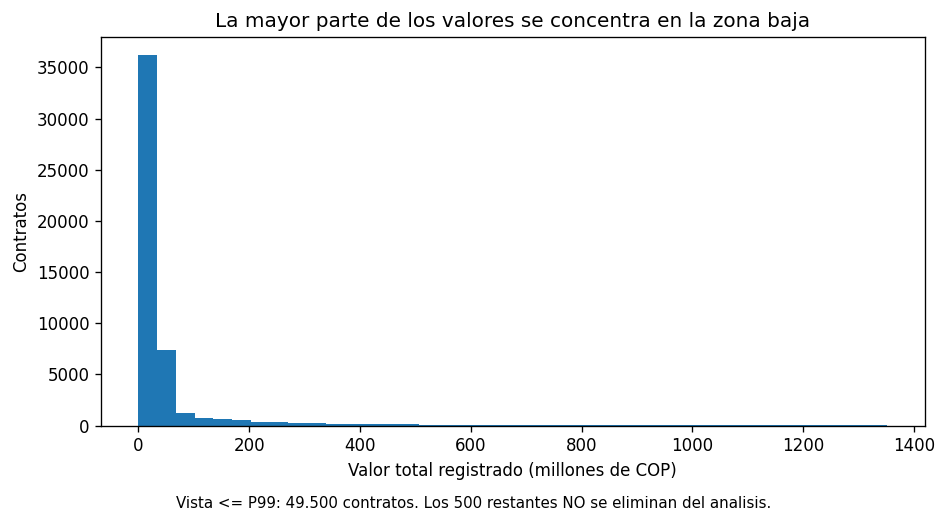

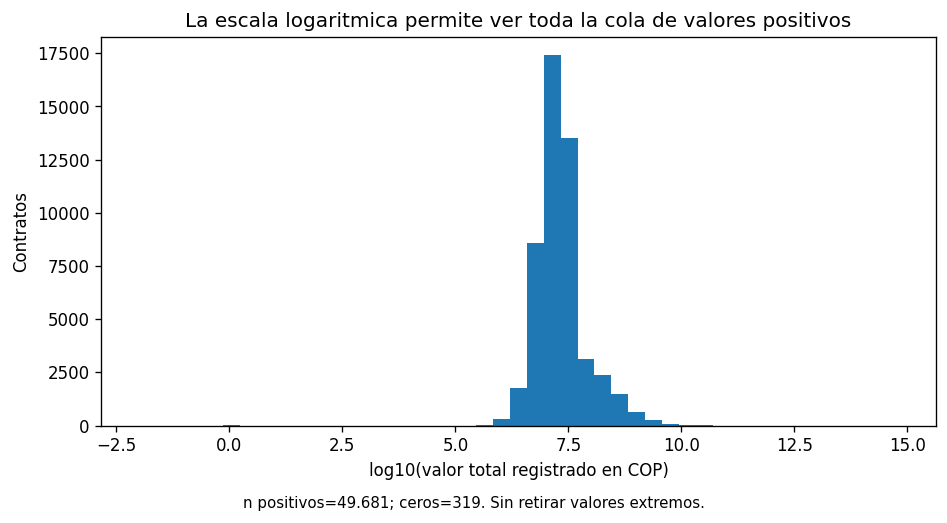

In [5]:
v = c['valor_del_contrato'].dropna()
value_summary = v.describe(percentiles=[.25, .5, .75, .90, .95, .99]).to_frame('COP')
save_table('resumen_valor', value_summary)
p99 = v.quantile(.99)
visible = v[v <= p99]
plt.figure(figsize=(8, 4.2))
plt.hist(visible / 1e6, bins=40)
plt.xlabel('Valor total registrado (millones de COP)')
plt.ylabel('Contratos')
plt.title('La mayor parte de los valores se concentra en la zona baja')
plt.figtext(.5, -.02, f'Vista <= P99: {fmt(len(visible))} contratos. Los {fmt(len(v)-len(visible))} restantes NO se eliminan del analisis.', ha='center', fontsize=9)
show_figure('perfil_histograma_lineal_p99')

positive = v[v > 0]
plt.figure(figsize=(8, 4.2))
plt.hist(np.log10(positive.astype(float)), bins=45)
plt.xlabel('log10(valor total registrado en COP)')
plt.ylabel('Contratos')
plt.title('La escala logaritmica permite ver toda la cola de valores positivos')
plt.figtext(.5, -.02, f'n positivos={fmt(len(positive))}; ceros={fmt(int(v.eq(0).sum()))}. Sin retirar valores extremos.', ha='center', fontsize=9)
show_figure('perfil_histograma_log')

### Respuestas sobre la distribución
La mediana describe mejor el valor central de este recorte que la media, porque un registro extremo domina la suma. Eso no vuelve incorrecto el cálculo de la media; vuelve inadecuado presentarla sola como contrato típico.

La vista lineal anterior **filtra solo la visualización** hasta P99 y declara cuántos registros deja fuera de la figura. No utiliza `clip`, que habría acumulado los extremos artificialmente en P99. Los registros siguen presentes en los cálculos principales. La segunda figura muestra todos los valores positivos en escala logarítmica; los ceros no tienen logaritmo.

## 4. Calidad: faltantes, identidades, ceros, extremos y fechas
Se inspeccionan todas las columnas. Además de nulos se identifican marcadores textuales de ausencia. No se aplica `dropna()` a todo el DataFrame.

In [6]:
markers = {'no definido', 'no definida', 'sin descripcion', 'no especificado'}
marker_count = contracts_raw.apply(lambda s: s.str.strip().str.lower().isin(markers).sum())
quality = pd.DataFrame({
    'faltantes': contracts_raw.isna().sum(),
    'porcentaje_faltante': contracts_raw.isna().mean()*100,
    'marcadores_sin_informacion': marker_count,
    'valores_distintos': contracts_raw.nunique(),
}).sort_values('porcentaje_faltante', ascending=False)
save_table('calidad_todas_columnas', quality)
q1, q3 = v.quantile([.25, .75])
iqr = q3 - q1
upper_iqr = q3 + 1.5*iqr
quality_counts = pd.Series({
    'filas_duplicadas_contratos': int(contracts_raw.duplicated().sum()),
    'IDs_duplicados_contratos_exceso': int(c['id_contrato'].duplicated().sum()),
    'valor_nulo': int(c['valor_del_contrato'].isna().sum()),
    'valor_cero': int(c['valor_del_contrato'].eq(0).sum()),
    'valor_negativo': int(c['valor_del_contrato'].lt(0).sum()),
    'umbral_superior_IQR_COP': upper_iqr,
    'candidatos_superiores_IQR': int(v.gt(upper_iqr).sum()),
    'duracion_faltante': int(c['duracion_registrada_dias'].isna().sum()),
    'duracion_negativa': int(c['duracion_registrada_dias'].lt(0).sum()),
    'duracion_cero': int(c['duracion_registrada_dias'].eq(0).sum()),
    'duracion_no_utilizable': int(c['duracion_valida_dias'].isna().sum()),
    'dias_adicionados_nulos': int(c['dias_adicionados'].isna().sum()),
    'dias_adicionados_negativos': int(c['dias_adicionados'].lt(0).sum()),
})
save_table('conteos_calidad', quality_counts.to_frame('resultado'))

worst = quality.head(3).index.tolist()
missing_patterns = (contracts_raw.assign(anio_firma=c['anio_firma'])
                    .groupby('anio_firma')[worst].agg(lambda s: s.isna().mean()*100))
save_table('faltantes_por_anio', missing_patterns)
missing_states = contracts_raw.groupby('estado_contrato')[worst].agg(lambda s: s.isna().mean()*100)
save_table('faltantes_por_estado', missing_states)

,faltantes,porcentaje_faltante,marcadores_sin_informacion,valores_distintos
fecha_de_notificaci_n_de_prorrogaci_n,42705,85.4100,0,723
fecha_fin_liquidacion,31753,63.5060,0,1168
fecha_inicio_liquidacion,31753,63.5060,0,1059
ultima_actualizacion,10014,20.0280,0,864
fecha_de_inicio_del_contrato,306,0.6120,0,770
...,...,...,...,...
nombre_ordenador_de_pago,0,0.0000,32553,481
n_mero_de_documento_ordenador_de_pago,0,0.0000,32553,486
documentos_tipo,0,0.0000,0,2
descripcion_documentos_tipo,0,0.0000,49650,10


,resultado
filas_duplicadas_contratos,0.0000
IDs_duplicados_contratos_exceso,0.0000
valor_nulo,0.0000
valor_cero,319.0000
valor_negativo,0.0000
umbral_superior_IQR_COP,"75,934,333.1250"
candidatos_superiores_IQR,"6,138.0000"
duracion_faltante,307.0000
duracion_negativa,11.0000
duracion_cero,301.0000


,fecha_de_notificaci_n_de_prorrogaci_n,fecha_fin_liquidacion,fecha_inicio_liquidacion
anio_firma,,,
2024,83.0669,61.2887,61.2887
2025,87.6205,65.5978,65.5978


,fecha_de_notificaci_n_de_prorrogaci_n,fecha_fin_liquidacion,fecha_inicio_liquidacion
estado_contrato,,,
Aprobado,93.6306,50.3185,50.3185
Borrador,100.0000,100.0000,100.0000
Cerrado,75.9452,62.7342,62.7342
En ejecución,95.3795,75.1428,75.1428
Modificado,89.2554,69.8673,69.8673
Suspendido,80.9859,35.9155,35.9155
cedido,94.0000,85.0000,85.0000
terminado,88.5307,55.7499,55.7499


### Diagnóstico de las tres columnas con más nulos
`fecha_de_notificaci_n_de_prorrogaci_n`, `fecha_inicio_liquidacion` y `fecha_fin_liquidacion` presentan mucha ausencia. Puede deberse a que no aplica esa etapa, a un proceso no terminado o a falta de reporte; **el archivo no permite escoger una causa única**. Se conservan y se contrastan sus patrones por año y estado. No se imputan fechas y no se deduce una prórroga inexistente a partir de una notificación vacía.

La duración se usa solo cuando inicio y fin están disponibles y la resta es positiva. Esa máscara no elimina el contrato de los análisis de valor o del cruce. Una duración igual a cero puede ser un evento del mismo día; se excluye de la duración positiva por definición, no se declara fraude ni error demostrado.

In [7]:
# Sensibilidad: cambiar el tratamiento sin borrar silenciosamente los datos.
subsets = {
    'todos_los_valores': v,
    'solo_positivos': v[v > 0],
    'positivos_hasta_su_P99': positive[positive <= positive.quantile(.99)],
    'sin_un_maximo': v.drop(v.idxmax()),
}
sensitivity_value = pd.DataFrame({name: {'n': len(s), 'mediana_COP': s.median(), 'media_COP': s.mean()}
                                  for name, s in subsets.items()}).T
save_table('sensibilidad_valor', sensitivity_value)
top5 = c.nlargest(5, 'valor_del_contrato')[[
    'id_contrato', 'nombre_entidad', 'tipo_de_contrato', 'valor_del_contrato',
    'objeto_del_contrato', 'urlproceso']].copy()
top5['clasificacion'] = [
    'Valor extremadamente alto frente al objeto; requiere documento fuente. No corregido.',
    'Escala muy alta para suministros; verificar unidades y documento. No corregido.',
    'Escala muy alta para el objeto descrito; verificar. No corregido.',
    'Escala alta en convenio; contrastar presupuesto y documento. No corregido.',
    'Operacion de credito: una magnitud alta podria ser plausible; no verificada.',
]
# Guardar detalle; mostrar extracto legible sin datos bancarios ni documentos personales.
top5.to_csv(OUT/'cinco_extremos_para_verificar.csv', index=False, encoding='utf-8-sig')
display(top5[['id_contrato', 'nombre_entidad', 'valor_del_contrato', 'clasificacion']])
share_max = float(v.max()/v.sum())
display(Markdown(f'El maximo registrado es **COP {fmt(v.max())}** y representa **{fmt(100*share_max, 4)}%** de la suma. '
                 f'La media completa es **COP {fmt(v.mean(), 2)}**; sin ese unico maximo es **COP {fmt(subsets["sin_un_maximo"].mean(), 2)}**. '
                 f'La mediana se mantiene en **COP {fmt(v.median())}**. Se marca el caso; no se cambia su valor sin soporte.'))

,n,mediana_COP,media_COP
todos_los_valores,"50,000.0000","18,000,000.0000","12,570,918,146.5032"
solo_positivos,"49,681.0000","18,052,467.0000","12,651,635,581.5133"
positivos_hasta_su_P99,"49,184.0000","18,000,000.0000","52,425,098.3997"
sin_un_maximo,"49,999.0000","18,000,000.0000","155,604,346.1916"


,id_contrato,nombre_entidad,valor_del_contrato,clasificacion
6742,CO1.PCCNTR.5800767,INSTITUTO TERMAL DE PAIPA,"620,765,845,619,929.0000",Valor extremadamente alto frente al objeto; re...
46344,CO1.PCCNTR.7466530,GOBERNACIÓN DE BOYACÁ,"2,385,617,800,000.0000",Escala muy alta para suministros; verificar un...
5704,CO1.PCCNTR.8396157,sutamarchan,"286,723,822,000.0000",Escala muy alta para el objeto descrito; verif...
39031,CO1.PCCNTR.7532714,ALCALDIA MUNICIPAL DE MIRAFLORES BOYACA,"122,865,088,569.0000",Escala alta en convenio; contrastar presupuest...
20823,CO1.PCCNTR.7136958,GOBERNACIÓN DE BOYACÁ,"85,441,601,702.0000",Operacion de credito: una magnitud alta podria...


El maximo registrado es **COP 620.765.845.619.929** y representa **98,7622%** de la suma. La media completa es **COP 12.570.918.146,50**; sin ese unico maximo es **COP 155.604.346,19**. La mediana se mantiene en **COP 18.000.000**. Se marca el caso; no se cambia su valor sin soporte.

## 5. Relacionar contratos y adiciones sin multiplicar contratos
**Orden:** validar llaves, revisar duplicados/conflictos, contar eventos únicos por contrato, unir el resumen y verificar que siguen existiendo 50.000 contratos.

El diccionario oficial de `cb9c-h8sn` define `identificador` como evento de **modificación**. Sus cinco columnas son identificador, ID del contrato, tipo, descripción y fecha. No incluye un monto adicionado estructurado. La etiqueta del conjunto no convierte una cesión, conclusión o modificación general en adición presupuestal.

La regla de conteo es `nunique(identificador)`. Los casos con un mismo evento y descripciones distintas quedan en un registro de conflictos; no se elige una descripción arbitraria como la verdadera. Si un identificador estuviera ligado a contratos diferentes, el código detendría el cruce.

In [8]:
assert a.groupby('identificador')['id_contrato'].nunique().max() == 1, 'Un evento se vincula con varios contratos.'
per_event = a.groupby('identificador')[['id_contrato', 'tipo', 'descripcion', 'fecharegistro']].nunique(dropna=False)
conflict_ids = per_event.index[per_event.gt(1).any(axis=1)]
conflict_rows = a[a['identificador'].isin(conflict_ids)].copy()
conflict_rows.to_csv(OUT/'conflictos_eventos.csv', index=False, encoding='utf-8-sig')
events = a[['identificador', 'id_contrato', 'fecha_registro_dt']].drop_duplicates()
assert events['identificador'].is_unique, 'Un mismo evento tiene fechas divergentes; requiere revision.'

duplicates_a = pd.Series({
    'filas_originales': len(additions_raw),
    'duplicados_exactos_exceso': int(additions_raw.duplicated().sum()),
    'filas_despues_de_duplicados_exactos': len(additions_raw.drop_duplicates()),
    'eventos_unicos': a['identificador'].nunique(),
    'IDs_evento_con_conflicto_de_atributos': len(conflict_ids),
    'IDs_evento_asociados_a_mas_de_un_contrato': int(per_event['id_contrato'].gt(1).sum()),
})
save_table('auditoria_duplicados_adiciones', duplicates_a.to_frame('resultado'))
save_table('tipos_modificacion_archivo', a['tipo'].value_counts().rename('filas').to_frame())

by_contract = events.groupby('id_contrato').agg(
    numero_registros_archivo=('identificador', 'nunique'),
    primer_registro_archivo=('fecha_registro_dt', 'min'),
    ultimo_registro_archivo=('fecha_registro_dt', 'max'),
).reset_index()
df = c.merge(by_contract, on='id_contrato', how='left', validate='one_to_one', indicator=True)
df['registro_localizado'] = df['_merge'].eq('both')
# Cero significa cero eventos EN ESTE ARCHIVO, no ausencia real de modificacion.
df['numero_registros_archivo'] = df['numero_registros_archivo'].fillna(0).astype(int)
assert len(df) == len(c) and df['id_contrato'].is_unique

matched_events = a.merge(c[['id_contrato', 'fecha_de_firma']], on='id_contrato', how='inner', validate='many_to_one')
matched_events['relacion_temporal'] = np.select(
    [matched_events['fecha_registro_dt'].lt(matched_events['fecha_de_firma']).to_numpy(dtype=bool),
     matched_events['fecha_registro_dt'].eq(matched_events['fecha_de_firma']).to_numpy(dtype=bool),
     matched_events['fecha_registro_dt'].gt(matched_events['fecha_de_firma']).to_numpy(dtype=bool)],
    ['anterior_a_firma', 'mismo_dia', 'posterior_a_firma'], default='fecha_desconocida')
matched_events.to_csv(OUT/'eventos_emparejados_auditados.csv', index=False, encoding='utf-8-sig')
post_ids = set(matched_events.loc[matched_events['relacion_temporal'].eq('posterior_a_firma'), 'id_contrato'])
pre_ids = set(matched_events.loc[matched_events['relacion_temporal'].eq('anterior_a_firma'), 'id_contrato'])
same_ids = set(matched_events.loc[matched_events['relacion_temporal'].eq('mismo_dia'), 'id_contrato'])
df['registro_posterior_localizado'] = df['id_contrato'].isin(post_ids)
financial_events = matched_events[matched_events['tipo'].eq('ADICION EN EL VALOR')].copy()
save_table('cronologia_eventos_emparejados', matched_events['relacion_temporal'].value_counts().rename('eventos').to_frame())
save_table('tipos_eventos_emparejados', matched_events['tipo'].value_counts().rename('eventos').to_frame())
print('Contratos con algun evento anterior:', len(pre_ids))
print('Contratos con algun evento posterior:', len(post_ids))
print('Contratos con etiqueta ADICION EN EL VALOR:', financial_events['id_contrato'].nunique())

,resultado
filas_originales,50000
duplicados_exactos_exceso,78
filas_despues_de_duplicados_exactos,49922
eventos_unicos,49912
IDs_evento_con_conflicto_de_atributos,10
IDs_evento_asociados_a_mas_de_un_contrato,0


,filas
tipo,
MODIFICACION GENERAL,27950
No definido,9678
CONCLUSION,8514
ADICION EN EL VALOR,1827
REACTIVACIoN,724
CESION,658
SUSPENSIoN,640
EXTENSION,7
REDUCCION EN EL VALOR,2


,eventos
relacion_temporal,
posterior_a_firma,55
anterior_a_firma,20
mismo_dia,1


,eventos
tipo,
MODIFICACION GENERAL,42
No definido,22
ADICION EN EL VALOR,11
CONCLUSION,1


Contratos con algun evento anterior: 19
Contratos con algun evento posterior: 54
Contratos con etiqueta ADICION EN EL VALOR: 11


### Respuestas del cruce y límite presupuestal
**¿Por qué agregar antes de unir?** Un contrato con dos eventos aparecería dos veces en un cruce directo: su valor se sumaría dos veces. Unir contra un resumen por contrato conserva la unidad de análisis.

**¿Qué cuenta el indicador?** `numero_registros_archivo` cuenta eventos distintos encontrados en el CSV. `registro_localizado` indica que se encontró al menos uno. El grupo falso se llama **sin registro localizado en esta descarga**; nunca se interpreta como contratos que no tuvieron adición.

**¿Qué significa posterior?** Solo la fecha del evento mayor que la fecha de firma satisface ese orden en los campos disponibles. Un evento del mismo día no permite establecer el orden intradía. Los eventos anteriores permanecen en la auditoría y se excluyen de la sensibilidad de registros posteriores; no se reparan fechas por conjetura.

**Razón exigida por el brief:**

**Proporción de adición presupuestal = valor adicionado validado / valor inicial validado.**

Para calcularla se necesitarían las cuantías de cada adición y el valor de firma, con una cobertura documentada. `valor_del_contrato` es un valor total registrado; `descripcion` es texto no estructurado y puede incluir montos de otras clases. No es válido usar pagos, saldos, número de eventos o días adicionados como numerador monetario. Las celdas siguientes registran la razón como no disponible y preparan una verificación documental para los eventos etiquetados en valor.

In [9]:
# No se fabrican valores iniciales ni montos adicionados.
df['valor_inicial_validado_COP'] = np.nan
df['valor_adicionado_validado_COP'] = np.nan
df['proporcion_adicion_presupuestal'] = np.nan
financial_review = financial_events[['identificador', 'id_contrato', 'tipo', 'descripcion', 'fecharegistro', 'relacion_temporal']].merge(
    c[['id_contrato', 'valor_del_contrato', 'urlproceso']], on='id_contrato', validate='many_to_one')
for col in ['valor_inicial_validado_COP', 'valor_adicionado_evento_validado_COP', 'documento_soporte', 'responsable_verificacion']:
    financial_review[col] = pd.NA
financial_review.to_csv(OUT/'protocolo_verificacion_monetaria.csv', index=False, encoding='utf-8-sig')
print('Razones monetarias calculables con variables validadas:', df['proporcion_adicion_presupuestal'].notna().sum())
print('La tabla de verificacion tiene', len(financial_review), 'eventos candidatos. Sus campos vacios no son ceros.')

Razones monetarias calculables con variables validadas: 0
La tabla de verificacion tiene 11 eventos candidatos. Sus campos vacios no son ceros.


## E1. Cobertura del cruce: una ausencia no es un contrato sin adición
**Pregunta:** ¿cuántos contratos pueden vincularse realmente a la tabla de modificaciones y qué limita esa lectura?

,resultado
contratos_total,"50,000.0000"
contratos_con_registro_localizado,74.0000
contratos_sin_registro_localizado,"49,926.0000"
porcentaje_con_registro_localizado,0.1480
eventos_emparejados,76.0000
filas_archivo_adiciones_no_emparejadas,"49,924.0000"
eventos_anteriores_a_firma,20.0000
contratos_con_evento_anterior_a_firma,19.0000
eventos_mismo_dia,1.0000
eventos_posteriores_a_firma,55.0000


,n,encontrados,porcentaje_localizado
anio_firma,,,
2024,24272,74,0.3049
2025,25728,0,0.0000


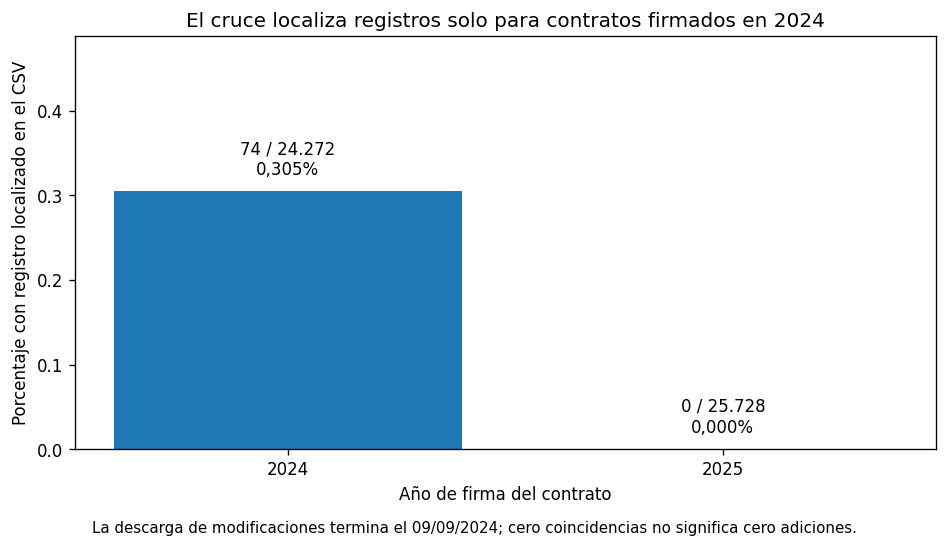

In [10]:
e1 = pd.Series({
    'contratos_total': len(df),
    'contratos_con_registro_localizado': int(df['registro_localizado'].sum()),
    'contratos_sin_registro_localizado': int((~df['registro_localizado']).sum()),
    'porcentaje_con_registro_localizado': float(df['registro_localizado'].mean()*100),
    'eventos_emparejados': len(matched_events),
    'filas_archivo_adiciones_no_emparejadas': len(a)-len(matched_events),
    'eventos_anteriores_a_firma': int(matched_events['relacion_temporal'].eq('anterior_a_firma').sum()),
    'contratos_con_evento_anterior_a_firma': len(pre_ids),
    'eventos_mismo_dia': int(matched_events['relacion_temporal'].eq('mismo_dia').sum()),
    'eventos_posteriores_a_firma': int(matched_events['relacion_temporal'].eq('posterior_a_firma').sum()),
    'contratos_con_evento_posterior_a_firma': len(post_ids),
})
save_table('E1_cobertura_cruce', e1.to_frame('resultado'))
coverage_year = df.groupby('anio_firma').agg(n=('id_contrato', 'size'), encontrados=('registro_localizado', 'sum'))
coverage_year['porcentaje_localizado'] = 100*coverage_year['encontrados']/coverage_year['n']
save_table('E1_cobertura_por_anio', coverage_year)
plt.figure(figsize=(8, 4.4))
xs = np.arange(len(coverage_year))
plt.bar(xs, coverage_year['porcentaje_localizado'].astype(float))
plt.xticks(xs, coverage_year.index.astype(str))
plt.ylim(0, max(.40, coverage_year['porcentaje_localizado'].max()*1.6))
plt.xlabel('Año de firma del contrato')
plt.ylabel('Porcentaje con registro localizado en el CSV')
plt.title('El cruce localiza registros solo para contratos firmados en 2024')
for x, (_, row) in zip(xs, coverage_year.iterrows()):
    plt.text(x, float(row['porcentaje_localizado'])+.02, f'{fmt(row["encontrados"])} / {fmt(row["n"])}\n{fmt(row["porcentaje_localizado"],3)}%', ha='center')
plt.figtext(.5, -.02, 'La descarga de modificaciones termina el 09/09/2024; cero coincidencias no significa cero adiciones.', ha='center', fontsize=9)
show_figure('E1_cobertura')

**Interpretación E1:** la llave es verificable y el cruce no multiplica filas, pero la cobertura del archivo auxiliar es insuficiente y desbalanceada en el tiempo. La proporción de coincidencias no es la tasa real de adición presupuestal ni temporal. Parte de los eventos emparejados presenta además un orden temporal incompatible con afirmar posterioridad.

**Hipótesis compatible:** el tope de la extracción nacional y su cobertura temporal restringida reducen las coincidencias con el recorte asignado. No se identifica el mecanismo exacto de selección.

**Duda pendiente:** ¿qué cambia al disponer de los eventos completos de los 50.000 IDs, con fechas verificadas y una misma ventana de seguimiento?

## E2. Comparar valores sin confundir localización con riesgo
**Pregunta:** ¿el valor total registrado difiere entre contratos con registro localizado y los demás contratos del recorte?

Se reportan n, P25, mediana y P75 por grupo. La comparación es descriptiva de una señal de localización, no de casos positivos y negativos presupuestales verdaderos.

,n_contratos,n_validos,P25,mediana,P75
registro_localizado,,,,,
Sin registro localizado,49926,49926,"9,961,500.0000","18,000,000.0000","36,343,641.2500"
Con registro localizado,74,74,"16,000,000.0000","23,820,000.0000","47,587,960.2500"


,n_contratos,n_validos,P25,mediana,P75
registro_localizado,,,,,
Sin registro localizado,49926,49308,71.0000,131.0000,211.0000
Con registro localizado,74,73,150.0000,204.0000,260.0000


Diferencia relativa de medianas (%): 32,3333
Mediana de eventos entre contratos con registro: 1.0


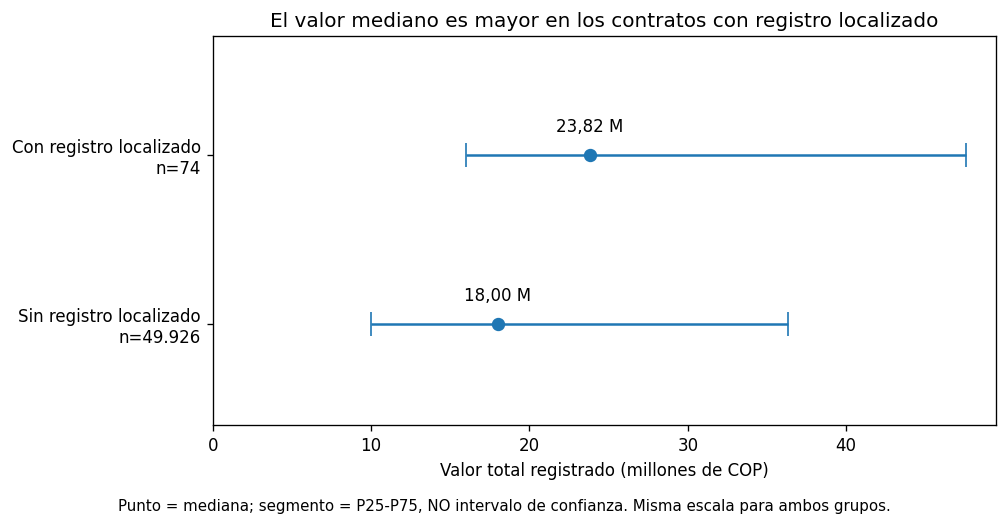

,n_contratos,n_validos,P25,mediana,P75
registro_posterior_localizado,,,,,
False,49926,49926,"9,961,500.0000","18,000,000.0000","36,343,641.2500"
True,54,54,"16,332,000.0000","24,182,000.0000","47,587,960.2500"


,n_contratos,n_validos,P25,mediana,P75
registro_localizado,,,,,
False,24198,24198,"9,000,000.0000","15,698,486.5000","30,493,888.5000"
True,74,74,"16,000,000.0000","23,820,000.0000","47,587,960.2500"


Caracteristica: modalidad_de_contratacion. Vista de las 8 categorias mas numerosas; tabla completa exportada.


,n_contratos,con_registro_localizado,con_dias_adicionados,mediana_valor_registrado_COP,sin_registro_localizado,cero_dias_adicionados_registrados,porcentaje_registro_localizado,porcentaje_con_dias_adicionados,celda_pequena
modalidad_de_contratacion,,,,,,,,,
Contratación directa,33577,41,2759,"15,000,000.0000",33536,30818,0.1221,8.2169,False
Mínima cuantía,6747,11,510,"24,000,000.0000",6736,6237,0.1630,7.5589,False
Contratación régimen especial,4202,15,578,"20,000,000.0000",4187,3624,0.3570,13.7554,False
Contratación Directa (con ofertas),1871,2,240,"127,770,814.1000",1869,1631,0.1069,12.8274,False
Contratación régimen especial (con ofertas),1646,1,219,"188,028,000.0000",1645,1427,0.0608,13.3050,False
Selección Abreviada de Menor Cuantía,966,4,204,"182,131,694.6700",962,762,0.4141,21.1180,False
Selección abreviada subasta inversa,661,0,115,"150,000,000.0000",661,546,0.0000,17.3979,False
Concurso de méritos abierto,148,0,55,"114,543,990.5100",148,93,0.0000,37.1622,False


Caracteristica: tipo_de_contrato. Vista de las 8 categorias mas numerosas; tabla completa exportada.


...

,n_contratos,con_registro_localizado,con_dias_adicionados,mediana_valor_registrado_COP,sin_registro_localizado,cero_dias_adicionados_registrados,porcentaje_registro_localizado,porcentaje_con_dias_adicionados,celda_pequena
nit_entidad,,,,,,,,,
891800498,7011,9,738,"25,272,000.0000",7002,6273,0.1284,10.5263,False
891800846,3118,1,127,"14,083,333.0000",3117,2991,0.0321,4.0731,False
899999034,2662,6,387,"38,686,000.0000",2656,2275,0.2254,14.5379,False
891855130,1667,2,361,"18,525,000.0000",1665,1306,0.1200,21.6557,False
800252843,1370,2,214,"21,764,850.0000",1368,1156,0.1460,15.6204,False
891800466,1205,3,72,"15,000,000.0000",1202,1133,0.2490,5.9751,False
899999239,1189,4,438,"27,863,241.0000",1185,751,0.3364,36.8377,False
891855138,1056,2,177,"20,122,671.5000",1054,879,0.1894,16.7614,False


Caracteristica: anio_firma. Vista de las 8 categorias mas numerosas; tabla completa exportada.


,n_contratos,con_registro_localizado,con_dias_adicionados,mediana_valor_registrado_COP,sin_registro_localizado,cero_dias_adicionados_registrados,porcentaje_registro_localizado,porcentaje_con_dias_adicionados,celda_pequena
anio_firma,,,,,,,,,
2025,25728,0,3730,"20,382,670.0000",25728,21998,0.0000,14.4978,False
2024,24272,74,1013,"15,750,000.0000",24198,23259,0.3049,4.1735,False


Caracteristica: mes_firma. Vista de las 8 categorias mas numerosas; tabla completa exportada.


,n_contratos,con_registro_localizado,con_dias_adicionados,mediana_valor_registrado_COP,sin_registro_localizado,cero_dias_adicionados_registrados,porcentaje_registro_localizado,porcentaje_con_dias_adicionados,celda_pequena
mes_firma,,,,,,,,,
2,7511,12,853,"22,750,000.0000",7499,6658,0.1598,11.3567,False
1,5929,4,669,"23,882,778.0000",5925,5260,0.0675,11.2835,False
9,4478,4,214,"11,963,650.0000",4474,4264,0.0893,4.7789,False
8,4372,5,318,"14,593,085.6500",4367,4054,0.1144,7.2736,False
3,4346,18,514,"21,622,998.0000",4328,3832,0.4142,11.8270,False
7,4094,5,331,"17,039,466.5000",4089,3763,0.1221,8.0850,False
10,3967,0,280,"9,749,396.0000",3967,3687,0.0000,7.0582,False
4,3644,18,330,"20,000,000.0000",3626,3314,0.4940,9.0560,False


In [11]:
def summarize_by_flag(frame, flag, value):
    return frame.groupby(flag, observed=True).agg(
        n_contratos=('id_contrato', 'size'), n_validos=(value, 'count'),
        P25=(value, lambda s:s.quantile(.25)), mediana=(value, 'median'),
        P75=(value, lambda s:s.quantile(.75)),
    )

e2 = summarize_by_flag(df, 'registro_localizado', 'valor_del_contrato')
e2.index = e2.index.map({False:'Sin registro localizado', True:'Con registro localizado'})
save_table('E2_comparacion_valor', e2)
e2_duration = summarize_by_flag(df, 'registro_localizado', 'duracion_valida_dias')
e2_duration.index = e2_duration.index.map({False:'Sin registro localizado', True:'Con registro localizado'})
save_table('E2_comparacion_duracion_positiva', e2_duration)
median_ratio_e2 = float(e2.loc['Con registro localizado', 'mediana']/e2.loc['Sin registro localizado', 'mediana'])
print('Diferencia relativa de medianas (%):', fmt((median_ratio_e2-1)*100, 4))
print('Mediana de eventos entre contratos con registro:', df.loc[df['registro_localizado'], 'numero_registros_archivo'].median())

def median_iqr_plot(table, filename, title, unit=1e6):
    plt.figure(figsize=(8.5, 4.2))
    ypos = np.arange(len(table))
    med = table['mediana'].to_numpy(dtype=float)/unit
    lo = table['P25'].to_numpy(dtype=float)/unit
    hi = table['P75'].to_numpy(dtype=float)/unit
    plt.errorbar(med, ypos, xerr=np.vstack([med-lo,hi-med]), fmt='o', capsize=7, markersize=7)
    plt.yticks(ypos, [f'{idx}\nn={fmt(row.n_contratos)}' for idx,row in table.iterrows()])
    plt.xlabel('Valor total registrado (millones de COP)')
    plt.ylabel('')
    plt.xlim(left=0)
    plt.ylim(-.6,len(table)-.3)
    plt.title(title)
    for pos,x in zip(ypos,med): plt.annotate(f'{fmt(x,2)} M', (x,pos), xytext=(0,14),textcoords='offset points',ha='center')
    plt.figtext(.5,-.025,'Punto = mediana; segmento = P25-P75, NO intervalo de confianza. Misma escala para ambos grupos.',ha='center',fontsize=9)
    show_figure(filename)
median_iqr_plot(e2, 'E2_valor_por_registro', 'El valor mediano es mayor en los contratos con registro localizado')

# Sensibilidad cronologica. Excluye de esta prueba contratos con eventos anteriores o del mismo dia.
chronology_clean = df[~df['id_contrato'].isin(pre_ids | same_ids)].copy()
save_table('E2_sensibilidad_solo_registro_posterior', summarize_by_flag(chronology_clean,'registro_posterior_localizado','valor_del_contrato'))
save_table('E2_sensibilidad_solo_firmas_2024', summarize_by_flag(df[df['anio_firma'].eq(2024)],'registro_localizado','valor_del_contrato'))

# Comparar todas las caracteristicas candidatas declaradas, no solo las que parecen llamativas.
# Son resumenes exploratorios del archivo, NO probabilidades de adicion presupuestal.
candidates = ['modalidad_de_contratacion', 'tipo_de_contrato', 'sector',
              'nit_entidad', 'anio_firma', 'mes_firma']
for feature in candidates:
    comparison = df.groupby(feature, dropna=False, observed=True).agg(
        n_contratos=('id_contrato','size'),
        con_registro_localizado=('registro_localizado','sum'),
        con_dias_adicionados=('con_dias_adicionados','sum'),
        mediana_valor_registrado_COP=('valor_del_contrato','median'))
    comparison['sin_registro_localizado'] = comparison['n_contratos']-comparison['con_registro_localizado']
    comparison['cero_dias_adicionados_registrados'] = comparison['n_contratos']-comparison['con_dias_adicionados']
    comparison['porcentaje_registro_localizado'] = 100*comparison['con_registro_localizado']/comparison['n_contratos']
    comparison['porcentaje_con_dias_adicionados'] = 100*comparison['con_dias_adicionados']/comparison['n_contratos']
    comparison['celda_pequena'] = comparison['n_contratos'] < MIN_CELDA
    comparison = comparison.sort_values('n_contratos', ascending=False)
    comparison.to_csv(OUT/f'comparacion_candidatas_{feature}.csv',encoding='utf-8-sig')
    print(f'Caracteristica: {feature}. Vista de las 8 categorias mas numerosas; tabla completa exportada.')
    display(comparison.head(8))
    assert comparison['n_contratos'].sum() == len(df)
    assert comparison['con_registro_localizado'].sum() == df['registro_localizado'].sum()
    assert comparison['con_dias_adicionados'].sum() == df['con_dias_adicionados'].sum()
# Las composiciones de entidades, sectores, meses y modalidades son desiguales.
# Compararlas no elimina la falta de cobertura, ni valida que valor y duracion sean iniciales.


**Interpretación E2:** la diferencia de valor existe en esta comparación del CSV y supera el umbral descriptivo propuesto. No prueba que un contrato más costoso cause adiciones ni que la medida sea observable desde la firma. Todos los registros localizados corresponden a firmas de 2024, mientras el grupo sin registro incluye firmas de 2025. Por eso se muestran sensibilidades de año y cronología.

La duración comparada utiliza solo restas positivas y publica el n válido. No se denomina duración inicial: una prórroga puede haber cambiado la fecha final. Usarla para predecir una modificación anterior introduciría información posterior al evento.

**Hipótesis compatible:** composición por modalidad, tipo, entidad y vigencia, junto con el mecanismo de extracción, puede explicar parte de la diferencia.

**Duda pendiente:** ¿se conserva la diferencia con cobertura completa, valores iniciales verificados y contratos comparables?

## E3. Ampliación temporal: análisis complementario del blog
**Pregunta:** ¿qué muestra `dias_adicionados` en el archivo de contratos?

Esta medida no depende del cruce incompleto. `dias_adicionados > 0` significa días adicionales registrados; cero significa que esa columna registra cero al corte. No significa ausencia de cualquier modificación, ni certifica que nunca habrá una prórroga. Es una **segunda definición de resultado**, temporal y explícita, no monetaria.

,n_contratos,n_validos,P25,mediana,P75
con_dias_adicionados,,,,,
Cero días adicionados registrados,45257,45257,"9,480,000.0000","16,800,000.0000","33,000,000.0000"
Con días adicionados registrados,4743,4743,"20,162,275.0000","39,742,818.0000","120,856,800.0000"


,resultado
contratos_con_dias_adicionados,"4,743.0000"
contratos_con_dato_de_dias,"50,000.0000"
porcentaje_con_dias_adicionados,9.4860
mediana_dias_entre_positivos,57.0000
P25_dias_entre_positivos,20.0000
P75_dias_entre_positivos,91.0000
maximo_dias_entre_positivos,926.0000
razon_de_medianas_valor,2.3656


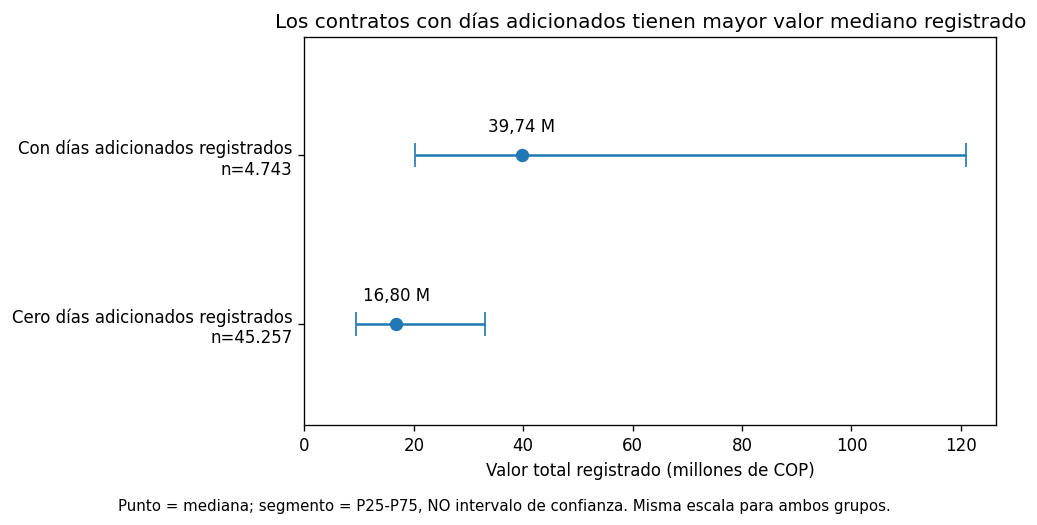

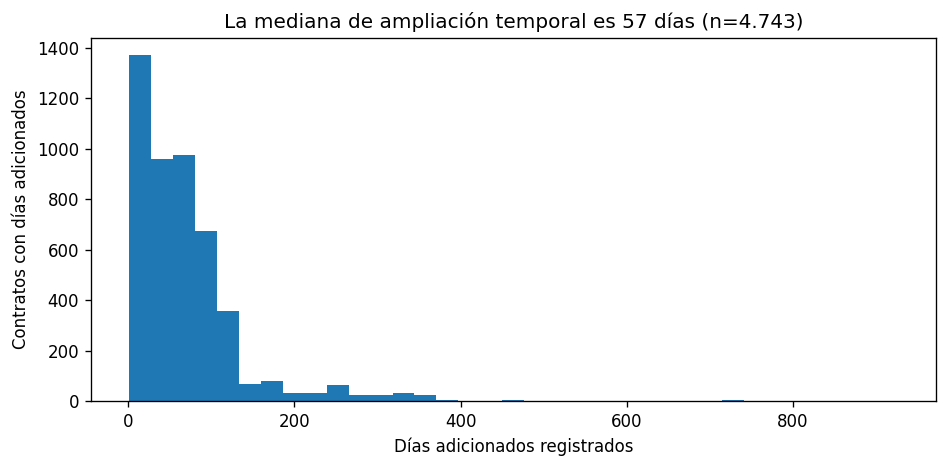

registro_localizado,False,True
con_dias_adicionados,,
False,45197,60
True,4729,14


In [12]:
days_known = df[df['con_dias_adicionados'].notna()].copy()
e3 = summarize_by_flag(days_known,'con_dias_adicionados','valor_del_contrato')
e3.index=e3.index.map({False:'Cero días adicionados registrados', True:'Con días adicionados registrados'})
save_table('E3_comparacion_temporal_valor', e3)
days_positive = df.loc[df['dias_adicionados'].gt(0),'dias_adicionados']
e3_totals = pd.Series({
    'contratos_con_dias_adicionados': len(days_positive),
    'contratos_con_dato_de_dias': len(days_known),
    'porcentaje_con_dias_adicionados': 100*len(days_positive)/len(days_known),
    'mediana_dias_entre_positivos': days_positive.median(),
    'P25_dias_entre_positivos': days_positive.quantile(.25),
    'P75_dias_entre_positivos': days_positive.quantile(.75),
    'maximo_dias_entre_positivos': days_positive.max(),
    'razon_de_medianas_valor': e3.iloc[1]['mediana']/e3.iloc[0]['mediana'],
})
save_table('E3_totales_temporales',e3_totals.to_frame('resultado'))
median_iqr_plot(e3,'E3_valor_por_dias','Los contratos con días adicionados tienen mayor valor mediano registrado')
plt.figure(figsize=(8,4))
plt.hist(days_positive.astype(float),bins=35)
plt.xlabel('Días adicionados registrados')
plt.ylabel('Contratos con días adicionados')
plt.title(f'La mediana de ampliación temporal es {fmt(days_positive.median())} días (n={fmt(len(days_positive))})')
show_figure('E3_distribucion_dias_positivos')
# No es una matriz de precision: los dos indicadores miden cosas diferentes.
save_table('E3_cruce_senales_distintas',pd.crosstab(df['con_dias_adicionados'],df['registro_localizado']))

**Interpretación E3:** hay una asociación descriptiva entre la señal temporal y el valor total registrado. La matriz entre esta señal y el cruce no se interpreta como sensibilidad o exactitud de un clasificador: ninguno es un patrón oro y miden eventos distintos.

**Hipótesis compatible:** contratos de mayor complejidad, determinadas modalidades o ciertas entidades pueden registrar tanto más valor como más días. Además, el valor al corte puede haberse actualizado.

**Duda pendiente:** ¿permanece la asociación dentro de la misma modalidad, tipo y vigencia, usando valor y duración iniciales verificados? Debe confirmarse con el docente si esta ruta temporal puede integrar el tablero del expediente presupuestal.

## 6. Tres decisiones de preparación para sustentar

### D1. Conservar un contrato por fila y contar eventos únicos
**Problema:** la tabla auxiliar repite eventos y contiene versiones de sus atributos.  
**Tratamiento implementado:** validar `id_contrato`, contar identificadores únicos, registrar conflictos y unir un resumen por contrato con `validate='one_to_one'`.  
**Evidencia:** auditoría de duplicados de la sección 5 y reconciliación E1.  
**Si está equivocada:** se pueden contar eventos o contratos de más, duplicar cuantías o perder modificaciones. No se afirma que la llave basta para resolver el problema de cobertura.

### D2. No convertir ausencia de coincidencia en ausencia real de adición
**Problema:** fechas incompletas para las cohortes, modificaciones de diferentes tipos y eventos anteriores a la firma.  
**Tratamiento implementado:** nombrar la variable `registro_localizado`; separar la sensibilidad de eventos posteriores y el resultado temporal; mantener la razón monetaria sin calcular.  
**Evidencia:** E1, tipos emparejados, cronología y columnas disponibles.  
**Si está equivocada:** se fabricarían negativos para 2025, confundirían terminaciones con aumentos presupuestales y podría inferirse causalidad con orden temporal incorrecto.

### D3. Conservar registros y usar resúmenes robustos y máscaras por variable
**Problema:** ceros, un valor dominante, faltantes y duraciones no positivas.  
**Tratamiento implementado:** conservar los contratos y sus valores, reportar mediana/P25/P75 y sensibilidades; usar duraciones positivas sin borrar contratos del resto del análisis. No corregir extremos sin documento.  
**Evidencia:** secciones 3-4 y tabla de sensibilidad.  
**Si está equivocada:** excluir registros sin motivo cambia la composición del recorte; conservar un error de valor distorsiona la media y la suma. Se muestran ambos riesgos.

Estas decisiones son las implementadas en el desarrollo asistido. El equipo debe verificarlas y ser capaz de defenderlas. Su validación no convierte retrospectivamente en propia una decisión que fue propuesta por IA.

## 6.1. Tablero de evidencia y cierre del primer avance
Las siguientes tres tarjetas se generan con las cifras calculadas. El archivo Word conserva exactamente estas tres evidencias y los cinco campos de la plantilla.

In [13]:
cards = [
 {'fuente':'E1',
  'hallazgo':'La descarga auxiliar tiene una cobertura insuficiente para estimar la frecuencia real de adiciones.',
  'cifra':f'{fmt(e1["contratos_con_registro_localizado"])} de {fmt(len(df))} contratos tienen registro localizado ({fmt(e1["porcentaje_con_registro_localizado"],3)}%); se emparejan {fmt(len(matched_events))} eventos. Todos los contratos localizados fueron firmados en 2024. La descarga de modificaciones termina el 09/09/2024.',
  'hipotesis':'El tope de 50.000 filas y la cobertura temporal del archivo nacional pueden explicar la baja coincidencia; no se conoce el mecanismo completo de selección.',
  'duda':'Obtener eventos completos de los IDs asignados y verificar fechas. Sin coincidencia no equivale a sin adición; hay eventos anteriores a la firma.'},
 {'fuente':'E2',
  'hallazgo':'Los contratos con registro localizado tienen mayor valor mediano registrado, pero la comparación no prueba riesgo presupuestal.',
  'cifra':f'Mediana COP {fmt(e2.iloc[1]["mediana"])} con registro (n={fmt(e2.iloc[1]["n_contratos"])}) frente a COP {fmt(e2.iloc[0]["mediana"])} sin registro localizado (n={fmt(e2.iloc[0]["n_contratos"])}). Diferencia relativa: {fmt((median_ratio_e2-1)*100,2)}%.',
  'hipotesis':'La composición por modalidad, tipo, entidad y vigencia, y la selección de la descarga, puede explicar parte de la diferencia.',
  'duda':'Repetir con cobertura completa, contratos comparables, fechas consistentes y valores iniciales validados. El valor al corte no demuestra el valor de firma.'},
 {'fuente':'E3',
  'hallazgo':'La señal temporal registra ampliaciones en parte del recorte y se asocia con un mayor valor mediano.',
  'cifra':f'{fmt(len(days_positive))}/{fmt(len(days_known))} contratos registran días adicionados ({fmt(100*len(days_positive)/len(days_known),3)}%). Mediana de ampliación: {fmt(days_positive.median()) } días. Valor mediano COP {fmt(e3.iloc[1]["mediana"])} frente a COP {fmt(e3.iloc[0]["mediana"])} con cero días registrados.',
  'hipotesis':'Diferencias de complejidad, modalidad o entidad, y posibles actualizaciones del valor, pueden estar relacionadas con ambas variables.',
  'duda':'Controlar modalidad, tipo y vigencia y verificar condiciones iniciales. Es una ruta temporal complementaria del blog; no reemplaza la razón presupuestal del brief.'}
]
for card in cards:
    display(Markdown('### '+card['fuente']+'\n\n'+'\n\n'.join('**'+key.title()+':** '+value for key,value in card.items() if key!='fuente')))
(OUT/'tarjetas_evidencia.json').write_text(json.dumps(cards,ensure_ascii=False,indent=2),encoding='utf-8')

### E1

**Hallazgo:** La descarga auxiliar tiene una cobertura insuficiente para estimar la frecuencia real de adiciones.

**Cifra:** 74 de 50.000 contratos tienen registro localizado (0,148%); se emparejan 76 eventos. Todos los contratos localizados fueron firmados en 2024. La descarga de modificaciones termina el 09/09/2024.

**Hipotesis:** El tope de 50.000 filas y la cobertura temporal del archivo nacional pueden explicar la baja coincidencia; no se conoce el mecanismo completo de selección.

**Duda:** Obtener eventos completos de los IDs asignados y verificar fechas. Sin coincidencia no equivale a sin adición; hay eventos anteriores a la firma.

### E2

**Hallazgo:** Los contratos con registro localizado tienen mayor valor mediano registrado, pero la comparación no prueba riesgo presupuestal.

**Cifra:** Mediana COP 23.820.000 con registro (n=74) frente a COP 18.000.000 sin registro localizado (n=49.926). Diferencia relativa: 32,33%.

**Hipotesis:** La composición por modalidad, tipo, entidad y vigencia, y la selección de la descarga, puede explicar parte de la diferencia.

**Duda:** Repetir con cobertura completa, contratos comparables, fechas consistentes y valores iniciales validados. El valor al corte no demuestra el valor de firma.

### E3

**Hallazgo:** La señal temporal registra ampliaciones en parte del recorte y se asocia con un mayor valor mediano.

**Cifra:** 4.743/50.000 contratos registran días adicionados (9,486%). Mediana de ampliación: 57 días. Valor mediano COP 39.742.818 frente a COP 16.800.000 con cero días registrados.

**Hipotesis:** Diferencias de complejidad, modalidad o entidad, y posibles actualizaciones del valor, pueden estar relacionadas con ambas variables.

**Duda:** Controlar modalidad, tipo y vigencia y verificar condiciones iniciales. Es una ruta temporal complementaria del blog; no reemplaza la razón presupuestal del brief.

2006

### Conclusión del primer avance
El recorte permite describir contratos, detectar problemas de calidad y mostrar diferencias entre grupos. Sin embargo, el cruce auxiliar no identifica la incidencia completa de adiciones y los datos estructurados no permiten calcular el cociente presupuestal pedido en el brief. Las asociaciones de localización de registros y de días adicionados se reportan por separado, sin causalidad ni predicción.

**Lo que sigue pendiente para la pregunta presupuestal:** el valor inicial validado, montos de eventos, cobertura suficiente y cronología contrastada. No es correcto afirmar ni que la afirmación monetaria quedó probada ni que los contratos sin coincidencia no crecieron.

**Recomendación inmediata:** presentar la auditoría, las tres decisiones y el tablero; pedir al docente confirmación del resultado evaluado y un archivo auxiliar compatible con el recorte si exige la medida presupuestal. No cambiar el recorte a otro departamento ni descargar una versión distinta sin dejar constancia.

---
# Anexo preparatorio: semana 2 (semana 8 del curso)
Este anexo aplica la objeción de trabajo escrita en el notebook base, no sustituye una tarjeta específica que el profesor entregue más adelante. El veredicto es **provisional y condicionado al alcance de las variables**.

## 7. Objeción, comparaciones conjuntas y respuesta
**Objeción del notebook:** ciertos tipos o modalidades pueden ser más costosos y más propensos a modificaciones; una comparación cruda puede mezclar composiciones.

**Tripleta de la ruta principal:** X = valor total registrado; Y = localización de registros; Z = tipo, modalidad y vigencia. La cobertura limita incluso una comparación estratificada.

**Tripleta complementaria:** X = cuartil global del valor registrado; Y = días adicionados positivos; Z = modalidad, tipo y año. Para no aparentar control con dos tablas marginales separadas, la comparación se repite **dentro de la misma combinación de Z**.

Se mantienen los puntos de corte globales de valor al comparar dentro de estratos. No se redefinen cuartiles en cada año, porque se estarían comparando intervalos de pesos diferentes. Los cuantiles pueden generar tamaños desiguales por empates.

,size,min,max
cuartil_valor,,,
Q1,12501,0.0000,"9,972,000.0000"
Q2,12613,"9,973,050.0000","18,000,000.0000"
Q3,12386,"18,004,000.0000","36,356,880.0000"
Q4,12500,"36,357,093.0000","620,765,845,619,929.0000"


,n,registros_localizados,con_dias,porcentaje_registro_localizado,porcentaje_con_dias,celda_pequena
cuartil_valor,,,,,,
Q1,12501,7,384,0.0560,3.0718,False
Q2,12613,19,630,0.1506,4.9948,False
Q3,12386,21,1131,0.1695,9.1313,False
Q4,12500,27,2598,0.2160,20.7840,False


,n,registros_localizados,con_dias,porcentaje_registro_localizado,porcentaje_con_dias,celda_pequena
modalidad_de_contratacion,,,,,,
Contratación directa,33577,41,2759,0.1221,8.2169,False
Mínima cuantía,6747,11,510,0.1630,7.5589,False
Contratación régimen especial,4202,15,578,0.3570,13.7554,False
Contratación Directa (con ofertas),1871,2,240,0.1069,12.8274,False
Contratación régimen especial (con ofertas),1646,1,219,0.0608,13.3050,False
Selección Abreviada de Menor Cuantía,966,4,204,0.4141,21.1180,False
Selección abreviada subasta inversa,661,0,115,0.0000,17.3979,False
Concurso de méritos abierto,148,0,55,0.0000,37.1622,False
Licitación pública,99,0,25,0.0000,25.2525,False


n  registros_localizados  con_dias  \
anio_firma cuartil_valor                                          
2024       Q1             5372                      5        73   
           Q2             5391                     11       127   
           Q3             4009                     17       141   
           Q4             1249                      6       116   
2025       Q1             3707                      0       183   
           Q2             4845                      0       370   
           Q3             4699                      0       704   
           Q4             2518                      0       739   

                          porcentaje_registro_localizado  porcentaje_con_dias  \
anio_firma cuartil_valor                                                        
2024       Q1                                     0.0931               1.3589   
           Q2                                     0.2040               2.3558   
           Q3                                     0.4240               3.5171   
           Q4                                     0.4804               9.2874   
2025       Q1                                     0.0000               4.9366   
           Q2                                     0.0000               7.6367   
           Q3                                     0.0000              14.9819   
           Q4                                     0.0000              29.3487   

                          celda_pequena  
anio_firma cuartil_valor                 
2024       Q1                     False  
           Q2                     False  
           Q3                     False  
           Q4                     False  
2025       Q1                     False  
           Q2                     False  
           Q3                     False  
           Q4                     False

,anio_firma,n_Q1,n_Q4,tasa_Q1,tasa_Q4,diferencia_Q4_Q1_pp
0,2024,5372,1249,1.3589,9.2874,7.9285
1,2025,3707,2518,4.9366,29.3487,24.4121


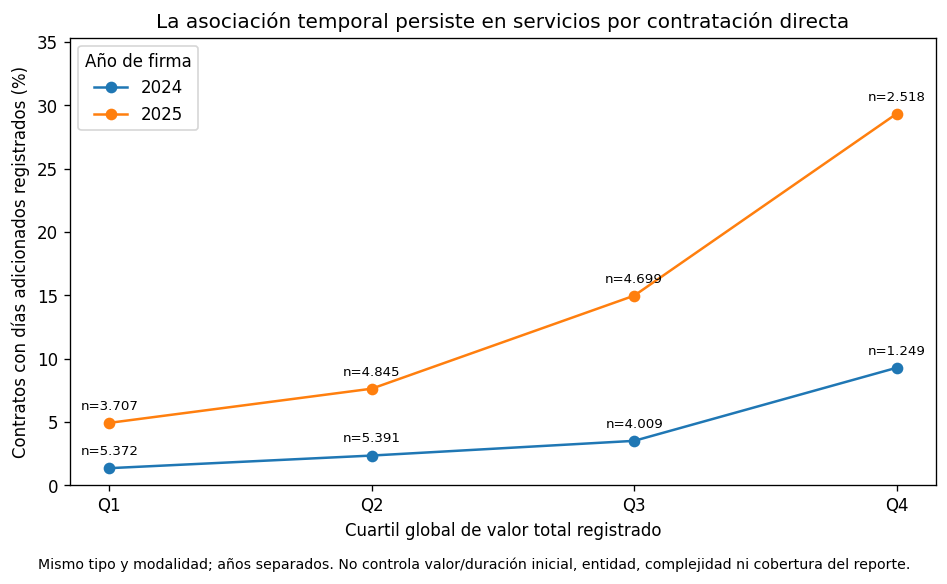

In [14]:
df['cuartil_valor'] = pd.qcut(df['valor_del_contrato'],4,labels=['Q1','Q2','Q3','Q4'])
quartile_bounds = df.groupby('cuartil_valor',observed=True)['valor_del_contrato'].agg(['size','min','max'])
save_table('S2_limites_cuartiles',quartile_bounds)

def rates(frame, keys):
    tab=frame.groupby(keys,observed=True).agg(n=('id_contrato','size'),
        registros_localizados=('registro_localizado','sum'),
        con_dias=('con_dias_adicionados','sum'))
    tab['porcentaje_registro_localizado']=100*tab['registros_localizados']/tab['n']
    tab['porcentaje_con_dias']=100*tab['con_dias']/tab['n']
    tab['celda_pequena']=tab['n']<MIN_CELDA
    return tab

rates_value=rates(df,['cuartil_valor'])
save_table('S2_tasas_por_cuartil',rates_value)
save_table('S2_tasas_por_modalidad',rates(df,['modalidad_de_contratacion']).sort_values('n',ascending=False))
joint=rates(df,['anio_firma','modalidad_de_contratacion','tipo_de_contrato','cuartil_valor'])
joint.to_csv(OUT/'S2_estratificacion_conjunta_completa.csv',encoding='utf-8-sig')
# Estrato definido por las categorias dominantes, no por maximizar la diferencia.
mode='Contratación directa'
ctype='Prestación de servicios'
comparable=df[df['modalidad_de_contratacion'].eq(mode)&df['tipo_de_contrato'].eq(ctype)]
controlled=rates(comparable,['anio_firma','cuartil_valor'])
save_table('S2_directa_servicios_por_anio_y_valor',controlled)
changes=[]
for year,tab in controlled.groupby(level=0):
    t=tab.droplevel(0)
    if {'Q1','Q4'}.issubset(t.index):
        changes.append({'anio_firma':int(year),'n_Q1':int(t.loc['Q1','n']),'n_Q4':int(t.loc['Q4','n']),
                        'tasa_Q1':float(t.loc['Q1','porcentaje_con_dias']),
                        'tasa_Q4':float(t.loc['Q4','porcentaje_con_dias']),
                        'diferencia_Q4_Q1_pp':float(t.loc['Q4','porcentaje_con_dias']-t.loc['Q1','porcentaje_con_dias'])})
controlled_diff=pd.DataFrame(changes)
save_table('S2_diferencias_controladas',controlled_diff,index=False)

plt.figure(figsize=(8,4.7))
for year,tab in controlled.groupby(level=0):
    t=tab.droplevel(0).reindex(['Q1','Q2','Q3','Q4'])
    plt.plot(np.arange(4),t['porcentaje_con_dias'].astype(float),marker='o',label=f'{year}')
    for x,(_,row) in enumerate(t.iterrows()):
        plt.annotate(f'n={fmt(row.n)}',(x,float(row.porcentaje_con_dias)),xytext=(0,8),textcoords='offset points',ha='center',fontsize=8)
plt.xticks(np.arange(4),['Q1','Q2','Q3','Q4'])
plt.ylim(bottom=0,top=float(controlled['porcentaje_con_dias'].max())+6)
plt.xlabel('Cuartil global de valor total registrado')
plt.ylabel('Contratos con días adicionados registrados (%)')
plt.title('La asociación temporal persiste en servicios por contratación directa')
plt.legend(title='Año de firma')
plt.figtext(.5,-.02,'Mismo tipo y modalidad; años separados. No controla valor/duración inicial, entidad, complejidad ni cobertura del reporte.',ha='center',fontsize=8.5)
show_figure('S2_figura_central_temporal')

### Respuesta provisional a la objeción
En la ruta temporal, la comparación de Q4 frente a Q1 permanece positiva dentro de servicios por contratación directa y en cada año. Eso reduce una explicación basada únicamente en mezclar modalidad, tipo y vigencia, pero no elimina las demás explicaciones. La figura central y la tabla muestran los tamaños y las tasas concretas.

La ruta de registros localizados continúa afectada por el archivo auxiliar incompleto. **Estratificar no recupera eventos ausentes ni convierte el valor total en valor inicial.** La ruta temporal no responde por sí sola al problema presupuestal.

**Veredicto provisional con las opciones del notebook:**
- Para la descripción restringida de asociaciones en los indicadores observados: **parcialmente respaldada**, con alcance exploratorio.
- Para la afirmación estricta sobre características iniciales y proporción de adición presupuestal posterior: **no respaldada por la evidencia disponible**. Esto significa insuficiencia de medición, no demostración de que la relación no exista.

La calificación final debe esperar la definición de resultado y la objeción que confirme el docente.

## 7.1. Potencia: aproximación didáctica del notebook base
Se conserva la aproximación normal para dos grupos del mismo tamaño, con alfa 0,05 y potencia 0,80. El tamaño de efecto d es una diferencia de medias estandarizada. **No es la potencia validada de nuestras diferencias de medianas, de las proporciones ni de una muestra truncada.** Tampoco se declara que un resultado sea significativo porque n sea grande.

In [15]:
alpha=.05
target_power=.80
normal=NormalDist()
z_alpha=normal.inv_cdf(1-alpha/2)
z_power=normal.inv_cdf(target_power)
power_table=pd.DataFrame([
    {'d_estandarizado':d,'alpha':alpha,'potencia_objetivo':target_power,
     'n_aproximado_por_grupo':math.ceil(2*((z_alpha+z_power)/d)**2)}
    for d in [.1,.2,.5,.8]
])
save_table('S2_potencia_didactica',power_table,index=False)

,d_estandarizado,alpha,potencia_objetivo,n_aproximado_por_grupo
0,0.1000,0.0500,0.8000,1570
1,0.2000,0.0500,0.8000,393
2,0.5000,0.0500,0.8000,63
3,0.8000,0.0500,0.8000,25


### Respuestas sobre potencia y causalidad
Un efecto menor requiere más observaciones para detectarse con la misma potencia. Miles de filas no corrigen una medición errónea, un archivo auxiliar incompleto, diferencias de seguimiento o confusión. El n grande del archivo principal no equivale a disponer de miles de eventos presupuestales observados.

Tres historias compatibles con la asociación temporal: (1) diferencias en condiciones iniciales podrían afectar la necesidad de ampliación; (2) una modificación podría cambiar el valor que hoy se observa; (3) complejidad, entidad u otra variable podría influir en ambas. El recorte al corte no identifica cuál historia es verdadera.

## 7.2. Diseño para evidencia más fuerte
**Comparación ideal sobre la afirmación original:** necesitaríamos contratos comparables, condiciones iniciales medidas antes de firmar y un seguimiento homogéneo de adiciones monetarias posteriores. No es defendible proponer asignar modalidad, cuantía o duración arbitrariamente: responden a necesidades y condiciones no intercambiables.

**Un experimento de intervención distinto y explícito:** si fuera autorizado y viable, asignar al azar un protocolo reforzado de planeación/revisión (A) frente al proceso habitual (B) entre contratos elegibles. Medir una variable de resultado predefinida, por ejemplo valor adicionado acumulado / valor inicial validado a 12 meses. Este experimento estudiaría el efecto del protocolo, **no probaría que el mayor valor inicial cause adiciones**.

**Alternativa observacional para el problema original:** cohorte longitudinal desde la firma; capturar valor y duración iniciales, modalidad, tipo, entidad, sector, objeto y vigencia; enlazar todas las modificaciones; distinguir adiciones de reducciones y prórrogas; comparar contratos de características semejantes y una ventana de seguimiento común. Estratificar o emparejar por variables medidas antes del resultado. Los cambios normativos o de implementación, si existieran y se verificaran, podrían permitir un diseño cuasi-experimental; aquí no se supone uno existente.

**Controlado en este anexo:** modalidad, tipo y año en la ruta temporal. **No controlado:** duración inicial, valor inicial verdadero, entidad dentro del estrato, complejidad, calidad del reporte y exposición completa. Estas limitaciones impiden causalidad.

## 8. Trazabilidad, exportación y verificaciones
Las salidas siguientes verifican las cifras del recorte suministrado y guardan tablas auditables. Los archivos no contienen pruebas de una irregularidad contractual. Las descripciones y URLs de revisión son pistas documentales, no resultados de comprobaciones externas ya hechas.

In [16]:
# Verificaciones independientes de reconciliacion sobre la instantanea recibida.
assert int(df['registro_localizado'].sum()) == len(set(c['id_contrato']) & set(a['id_contrato'])) == 74
assert len(matched_events) == int(a['id_contrato'].isin(c['id_contrato']).sum()) == 76
assert len(df) == 50000
assert int(df['con_dias_adicionados'].sum()) == 4743
assert int(df['registro_posterior_localizado'].sum()) == 54
assert matched_events['relacion_temporal'].eq('anterior_a_firma').sum() == 20
assert int(e2.loc['Con registro localizado','mediana']) == 23820000
assert int(e2.loc['Sin registro localizado','mediana']) == 18000000
assert int(e3.iloc[1]['mediana']) == 39742818
assert df['proporcion_adicion_presupuestal'].isna().all()
assert a.loc[a['identificador'].isin(conflict_ids),'id_contrato'].isin(c['id_contrato']).sum() == 0

metrics={
    'n_contratos':len(df),'n_columnas_contratos':contracts_raw.shape[1],
    'n_adiciones_filas':len(a),'n_eventos_unicos':a['identificador'].nunique(),
    'n_contratos_localizados':int(df['registro_localizado'].sum()),
    'n_eventos_emparejados':len(matched_events),
    'porcentaje_localizados':float(df['registro_localizado'].mean()*100),
    'mediana_valor_COP':float(v.median()),'media_valor_COP':float(v.mean()),
    'maximo_valor_COP':float(v.max()),'fraccion_suma_maximo':share_max,
    'ceros':int(v.eq(0).sum()),'duraciones_no_utilizables':int(c['duracion_valida_dias'].isna().sum()),
    'contratos_dias_positivos':len(days_positive),'porcentaje_dias_positivos':100*len(days_positive)/len(days_known),
    'mediana_dias_positivos':float(days_positive.median()),
    'mediana_valor_con_registro':float(e2.iloc[1]['mediana']),
    'mediana_valor_sin_registro':float(e2.iloc[0]['mediana']),
    'diferencia_relativa_mediana_registro_pct':float((median_ratio_e2-1)*100),
    'mediana_valor_con_dias':float(e3.iloc[1]['mediana']),
    'mediana_valor_cero_dias':float(e3.iloc[0]['mediana']),
    'eventos_anteriores_firma':int(matched_events['relacion_temporal'].eq('anterior_a_firma').sum()),'contratos_con_eventos_anteriores_firma':len(pre_ids),
    'eventos_posteriores_firma':int(matched_events['relacion_temporal'].eq('posterior_a_firma').sum()),'contratos_con_eventos_posteriores_firma':len(post_ids),
    'eventos_etiquetados_adicion_valor':len(financial_events),
    'fecha_maxima_registros':str(a['fecha_registro_dt'].max().date()),
    'control_temporal_por_anio':controlled_diff.to_dict('records'),
    'verificaciones':'superadas'
}
(OUT/'metricas_clave.json').write_text(json.dumps(metrics,ensure_ascii=False,indent=2),encoding='utf-8')
export_cols=['id_contrato','nombre_entidad','anio_firma','mes_firma','modalidad_de_contratacion','tipo_de_contrato',
             'valor_del_contrato','duracion_valida_dias','dias_adicionados','numero_registros_archivo',
             'registro_localizado','registro_posterior_localizado','con_dias_adicionados']
df[export_cols].to_csv(OUT/'base_analitica_minima.csv',index=False,encoding='utf-8-sig')
print('VERIFICACIONES SUPERADAS. Tablas y figuras guardadas en',OUT)

VERIFICACIONES SUPERADAS. Tablas y figuras guardadas en /mnt/data/Equipo9_ExpedienteD/resultados


## 9. Declaración de uso de inteligencia artificial
**Herramienta:** ChatGPT.  
**Actividades asistidas:** revisión de materiales, propuesta de código, auditoría del cruce, cálculos, gráficas, redacción y preparación para sustentar.  
**Verificación técnica realizada en el desarrollo:** ejecución desde cero con los CSV identificados por SHA-256; conservación de contratos; conciliación por intersección de IDs; conteo de eventos únicos; pruebas de fechas y medianas. Estas pruebas no sustituyen la revisión humana del equipo ni la validación documental de montos.  
**Verificación del equipo:** pendiente de registrar por los integrantes después de ejecutar y contrastar los resultados.  
**Decisión no delegada:** pendiente de diligenciar con una decisión tomada realmente por el equipo. No se debe declarar como autónoma una decisión propuesta aquí por la herramienta.

## 10. Fuentes y alcance documental
**Material docente revisado:** `Brief_Expediente_D(2).docx`, `SECOP_ExpedienteD(2).ipynb`, `Copia de SECOP_ExpedienteD_Grupo9(2).ipynb`, `1 EDA(2).pptx`, `2 Asociación - evidencia(2).pptx`, `Blog_DataAnalytics_SECOP-EDA(2).html`, dos copias idénticas de la plantilla y los cuatro archivos del ZIP del equipo 9. Las imágenes del blog son ilustrativas; no se usan como cifras del equipo.

La Guía general versión 2.0 mencionada en el brief no forma parte de estos adjuntos. Tampoco hay una fecha/hora inequívoca de entrega ni una tarjeta nueva de objeción asignada al equipo. Se distinguen esas ausencias del trabajo sí ejecutado.

**Consulta externa de definiciones (21/09/2026; no se reemplazaron los CSV):**
- Colombia Compra Eficiente: [SECOP II - Adiciones, esquema oficial](https://www.datos.gov.co/Estad-sticas-Nacionales/SECOP-II-Adiciones/cb9c-h8sn). El evento es una modificación y el esquema tiene cinco campos.
- Colombia Compra Eficiente / Socrata: [Contratos Electrónicos, diccionario](https://dev.socrata.com/foundry/www.datos.gov.co/jbjy-vk9h). Valor total, días adicionados y definiciones de fechas.
- pandas: [DataFrame.merge](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html). Validación de cardinalidad e indicador del cruce.

Los valores extremos no fueron contrastados con documentos contractuales originales. Se revisó su objeto en el CSV y se dejó la verificación externa pendiente; no se cambió ninguna cuantía.